###  Connecting to Neo4j

In [ ]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j+s://8c7b06ba.databases.neo4j.io"
USERNAME = "8c7b06ba"
PASSWORD = "qD0ehEZuPfSVjJ5F6oNsxIrF297R3ckAEmIM0DZ296Y"

driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 37.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.0/274.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.1/64.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 40.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 6.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Helper to run queries

In [9]:
def run_query(query, params=None):
    with driver.session() as session:
        result = session.run(query, params or {})
        return [record.data() for record in result]

def run_df(query, params=None):
    return pd.DataFrame(run_query(query, params))

### Loading data files

In [10]:
base_path = "/Users/kalafejzo/mids205_project3_kala/data"

users = pd.read_csv(f"{base_path}/users.csv")
friend_edges = pd.read_csv(f"{base_path}/friend_edges.csv")
posts = pd.read_csv(f"{base_path}/posts.csv")
likes = pd.read_csv(f"{base_path}/likes.csv")
circles = pd.read_csv(f"{base_path}/all_circles.csv")

### Loading users

In [11]:
def load_users(tx, rows):
    query = """
    UNWIND $rows AS row
    MERGE (u:User {user_id: toInteger(row.user_id)})
    SET u.is_ego = CASE
      WHEN row.is_ego IN [True, 'True', 'true', 1, '1'] THEN true
      ELSE false
    END,
    u.degree = toInteger(row.degree),
    u.circle_count = toInteger(row.circle_count),
    u.ego_network_count = toInteger(row.ego_network_count),
    u.primary_ego_id = CASE
      WHEN row.primary_ego_id IS NULL OR row.primary_ego_id = '' THEN NULL
      ELSE toInteger(row.primary_ego_id)
    END
    """
    tx.run(query, rows=rows)

with driver.session() as session:
    session.execute_write(load_users, users.to_dict("records"))

### Loading Friendships


In [12]:
def load_friend_edges(tx, rows):
    query = """
    UNWIND $rows AS row
    MATCH (u1:User {user_id: toInteger(row.source)})
    MATCH (u2:User {user_id: toInteger(row.target)})
    MERGE (u1)-[:FRIENDS_WITH]->(u2)
    """
    tx.run(query, rows=rows)

with driver.session() as session:
    session.execute_write(load_friend_edges, friend_edges.to_dict("records"))

### Loading Posts

In [13]:
def load_posts(tx, rows):
    query = """
    UNWIND $rows AS row
    MATCH (u:User {user_id: toInteger(row.user_id)})
    MERGE (p:Post {post_id: row.post_id})
    SET p.topic_circle = row.topic_circle,
        p.engagement_seed = toFloat(row.engagement_seed)
    MERGE (u)-[:POSTED]->(p)
    """
    tx.run(query, rows=rows)

with driver.session() as session:
    session.execute_write(load_posts, posts.to_dict("records"))

### Loading Likes

In [14]:
def load_likes(tx, rows):
    query = """
    UNWIND $rows AS row
    MATCH (u:User {user_id: toInteger(row.user_id)})
    MATCH (p:Post {post_id: row.post_id})
    MERGE (u)-[:LIKED]->(p)
    """
    tx.run(query, rows=rows)

with driver.session() as session:
    session.execute_write(load_likes, likes.to_dict("records"))

### Loading circles

In [15]:
def load_circles(tx, rows):
    query = """
    UNWIND $rows AS row
    MERGE (c:Circle {circle_key: toString(row.ego_id) + '_' + row.circle_name})
    SET c.ego_id = toInteger(row.ego_id),
        c.circle_name = row.circle_name
    """
    tx.run(query, rows=rows)

def load_circle_memberships(tx, rows):
    query = """
    UNWIND $rows AS row
    MATCH (u:User {user_id: toInteger(row.member_id)})
    MATCH (c:Circle {circle_key: toString(row.ego_id) + '_' + row.circle_name})
    MERGE (u)-[:MEMBER_OF]->(c)
    """
    tx.run(query, rows=rows)

### Loads in batches

In [16]:
def batch_records(df, batch_size=1000):
    for start in range(0, len(df), batch_size):
        yield df.iloc[start:start+batch_size].to_dict("records")

with driver.session() as session:
    for batch in batch_records(circles, 1000):
        session.execute_write(load_circles, batch)

with driver.session() as session:
    for batch in batch_records(circles, 1000):
        session.execute_write(load_circle_memberships, batch)

### Run Degree Centrality Algorithm
Finds the most highly connected users in the network, allowing us to identify influential nodes that may play a key role in information dissemination and engagement.

<Axes: xlabel='user_id'>

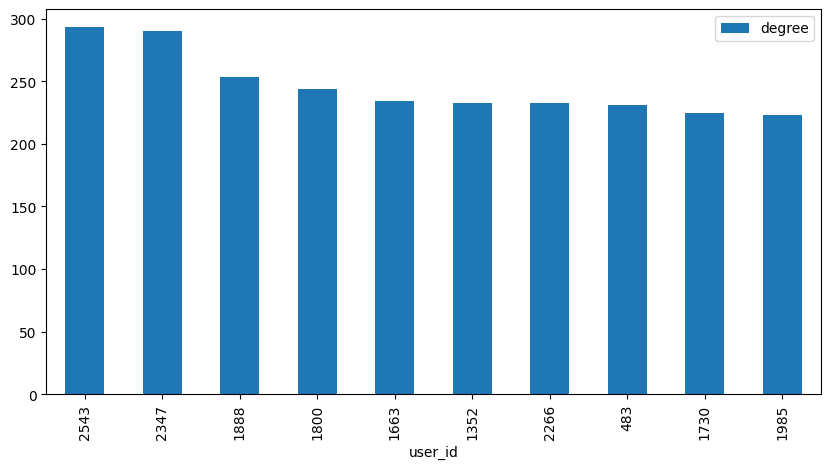

In [19]:
degree_df = run_df("""
MATCH (u:User)-[:FRIENDS_WITH]-()
RETURN u.user_id AS user_id,
       count(*) AS degree
ORDER BY degree DESC
LIMIT 10
""")

degree_df
degree_df.plot.bar(x='user_id', y='degree', figsize=(10,5))